### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

TELESCU Maxime
Romain
Placide

/tmp/ipykernel_6497/1152338907.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


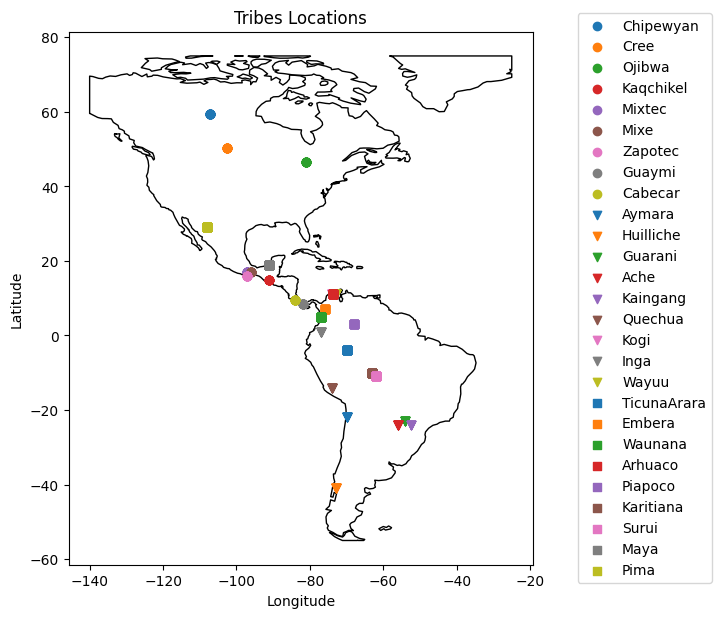

In [23]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extracting relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
#Showing the part of the map we are interested in, north center and south america
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [24]:
import numpy as np
import pandas as pd

predictors = df.columns[8:]
X = df[predictors].values
y = df['long'].values

# Let's calculate X^T * X and X^T * y
XtX = X.T @ X
Xty = X.T @ y

# Try to solve the system of equations
try:
    beta_a = np.linalg.solve(XtX, Xty)
    print("Success!")
except np.linalg.LinAlgError as e:
    print(f"Encountered an error: {e}")

Encountered an error: Singular matrix


We obtain a "Singular matrix" error. Indeed, since matrix X has dimension N×p (with N<p), its maximum possible rank is N. Consequently, the matrix X⊤X, which is of dimension p×p, will have a rank necessarily lower than or equal to min(N,p)=N. Because N<p, the rank of X⊤X is strictly lower than p. Therefore, the square matrix X⊤X is not full rank and cannot be inverted.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [27]:
import numpy as np

# rcond=None for estimating the rank
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print(f"Number of coef (p) : {len(beta_lstsq)}")
print(f"Rank of matrix X: {rank}")
print(f"Residuals : {residuals}")

Number of coef (p) : 5709
Rank of matrix X: 494
Residuals : []


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [28]:
from sklearn.linear_model import LinearRegression
import numpy as np

# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']

# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

# Comparison with beta from part (b)
print(f"First 5 coefficients (sklearn): {lr.coef_[:5]}")
print(f"First 5 coefficients (lstsq):   {beta_lstsq[:5]}")

# Check if they are identical by computing the difference
diff = np.linalg.norm(lr.coef_ - beta_lstsq)
print(f"\nDifference (L2 norm): {diff:.4e}")

First 5 coefficients (sklearn): [-0.03940988 -0.0245272   0.01089763  0.01066482 -0.02470103]
First 5 coefficients (lstsq):   [-0.04005781 -0.01940898  0.01111306 -0.01234685 -0.02460976]

Difference (L2 norm): 6.3466e+00


Sklearn works with centered data, which is why we obtain such a difference, an error of 6 approximately, based on L2 norm on vectors !

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

PCA is used in order to reduce the dimensionality of a large dataset while keeping the majority of its information.

Statistical interpretation:
PCA transforms the original variables into a new set of linearly independent (orthogonal) variables called Principal Components. These components are ordered by the amount of variance they capture from the original data(eightenvalues ordered). The first principal component (PC1) is the direction that maximizes the variance of the projected data(biggest eightenvalue associated). The second component (PC2) captures the maximum amount of the remaining variance while being strictly orthogonal to the first one, and so on. Mathematically, these directions correspond to the eigenvectors of the data's covariance matrix, and their corresponding eigenvalues represent the amount of variance explained by each axis.

Geometric interpretation:
Geometrically, PCA seeks a lower-dimensional subspace (such as a line, a plane, or a hyperplane) that "best fits" the n-dimensional cloud of original data points. In this context, the "best fit" is the subspace that minimizes the total reconstruction error, which is defined as the sum of the squared perpendicular distances from the original data points to their projections on this new subspace. Minimizing this projection distance is mathematically equivalent to maximizing the variance of the projected points.


**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

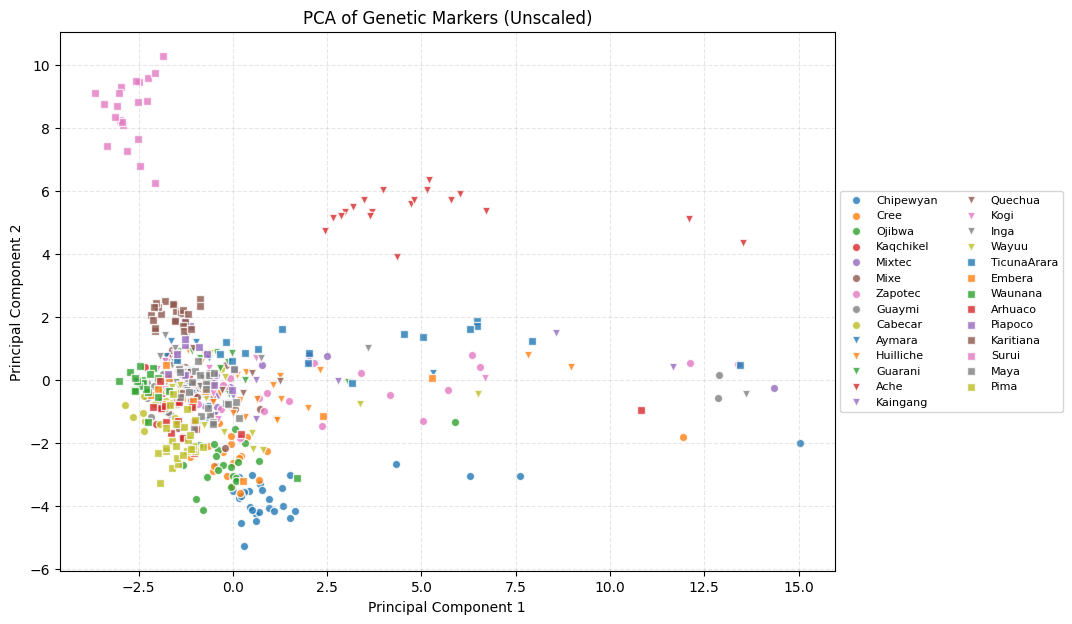

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Initialize PCA to keep the first 2 components
pca = PCA(n_components=2)

# 2. Fit and transform the genetic data (X)
X_pca = pca.fit_transform(X)

# 3. Plotting the results
fig, ax = plt.subplots(figsize=(10, 7))

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

# Loop through each unique tribe to plot them
for i, tribe in enumerate(df['Pop'].unique()):
    idx = (df['Pop'] == tribe)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
               marker=marker_list[i // 9], 
               color=colors_list[i % 9], 
               label=tribe, 
               alpha=0.8, edgecolors='w')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Genetic Markers (Unscaled)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize='8')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

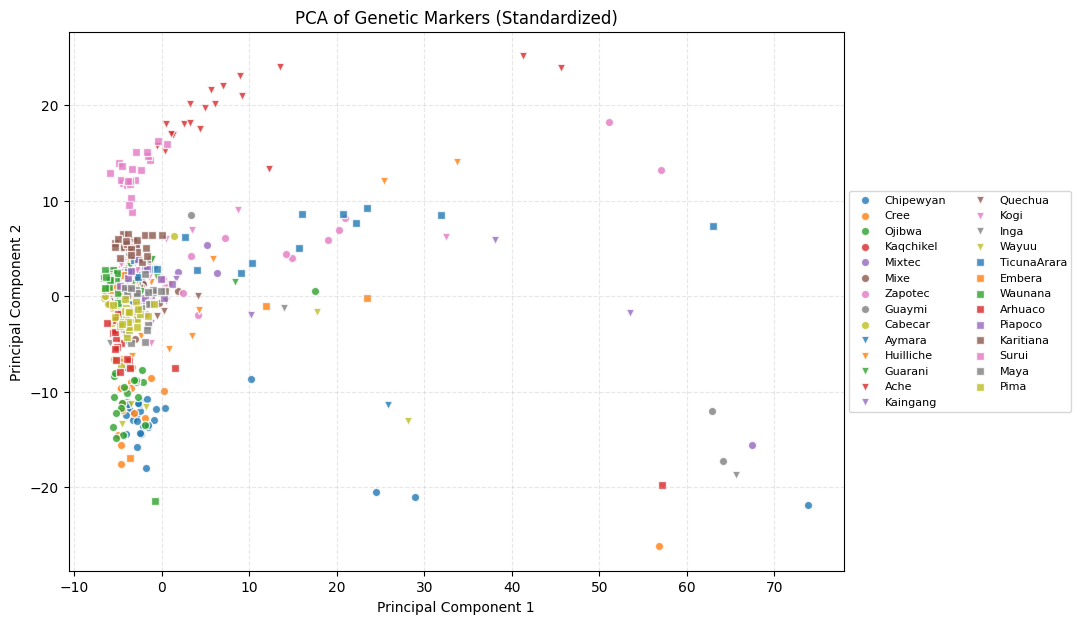

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 2. Fit PCA on the standardized data
pca_std = PCA(n_components=2)
X_pca_std = pca_std.fit_transform(X_std)

# 3. Plotting the results
fig, ax = plt.subplots(figsize=(10, 7))

# Markers and colors
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(df['Pop'].unique()):
    idx = (df['Pop'] == tribe)
    ax.scatter(X_pca_std[idx, 0], X_pca_std[idx, 1], 
               marker=marker_list[i // 9], 
               color=colors_list[i % 9], 
               label=tribe, 
               alpha=0.8, edgecolors='w')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Genetic Markers (Standardized)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, fontsize='8')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

The new graph is really similar to the previous one, though the major difference is located on both axes which aren't scaled similiarly.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

We don't think the scaling was a necessity, but it's allowing us to trust better the new data, now we're sure there aren't any vector with enormous norm.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Number of PC:494
Percentage of variance captured by the first two PCs: 3.57%
Percentage for 1 PC: 2.05
Percentage for 2 PC: 3.57
Percentage for 3 PC: 4.90
Percentage for 4 PC: 6.15
Percentage for 5 PC: 7.28
Percentage for 6 PC: 8.28
Percentage for 7 PC: 9.20
Percentage for 8 PC: 10.05
Percentage for 9 PC: 10.81
Percentage for 10 PC: 11.54
Percentage for 11 PC: 12.19


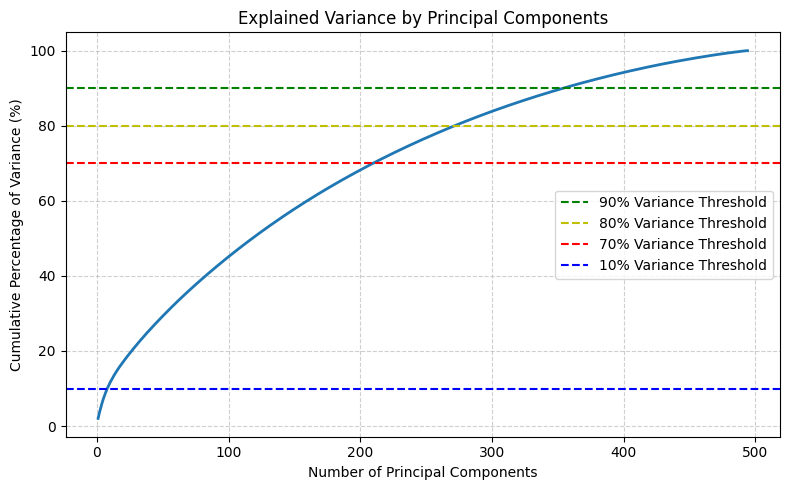

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X)

# 1. Get the "percentage" of variance captured by the first two components
explained_var_ratio = pca_full.explained_variance_ratio_
print(f"Number of PC:{len(explained_var_ratio)}");
# No need of adding the covariance since the vectors are orthogonals
var_pc1_pc2 = (explained_var_ratio[0] + explained_var_ratio[1]) * 100 
print(f"Percentage of variance captured by the first two PCs: {var_pc1_pc2:.2f}%")

# 2. Plot the cumulative percentage of variance
cumulative_variance = np.cumsum(explained_var_ratio) * 100
for i in range(0, 11):
    print(f"Percentage for {i + 1} PC: {cumulative_variance[i]:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)

# 90% threshold line
ax.axhline(y=90, color='g', linestyle='--', label='90% Variance Threshold')

# 80% threshold line
ax.axhline(y=80, color='y', linestyle='--', label='80% Variance Threshold')

# 70% threshold line
ax.axhline(y=70, color='r', linestyle='--', label='70% Variance Threshold')

# 10% threshold line
ax.axhline(y=10, color='b', linestyle='--', label='10% Variance Threshold')

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Percentage of Variance (%)')
ax.set_title('Explained Variance by Principal Components')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


We clearly see that two PC aren't enought, they give only 3.57% of variance of the whole model.
We would like to use most of the PC, but it won't be efficient since it would create a huge overfitting.
With about 200 PC we can represent a bit less than 70% of the variance of the model, it sounds like a good number, not to much, not too little.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

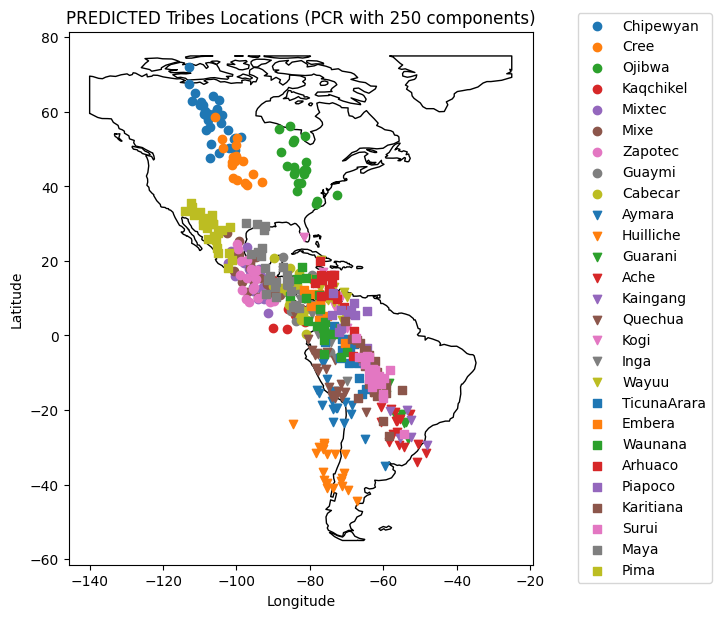

In [17]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import haversine_distances
import numpy as np
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# ==========================================
# (a) PCR with 250 components
# ==========================================

# 1. PCA with 250 components on unscaled data
pca_250 = PCA(n_components=250)
X_pca_250 = pca_250.fit_transform(X)

# 2. Extract targets (Latitude and Longitude)
y_coords = df[['lat', 'long']].values 

# 3. Fit the Linear Regression
lr_pcr = LinearRegression()
lr_pcr.fit(X_pca_250, y_coords)

# 4. Predict the coordinates
y_pred = lr_pcr.predict(X_pca_250)

# Create a new DataFrame for plotting predicted points
df_pred = df.copy()
df_pred['lat_pred'] = y_pred[:, 0]
df_pred['long_pred'] = y_pred[:, 1]
gdf_pred = gpd.GeoDataFrame(df_pred, geometry=gpd.points_from_xy(df_pred.long_pred, df_pred.lat_pred))

# 5. Plotting the "predicted" locations
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]

for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    ax.scatter(members_tribe['long_pred'], members_tribe['lat_pred'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PREDICTED Tribes Locations (PCR with 250 components)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()


**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [19]:
# ==========================================
# (b) Quantifying the error in kilometers
# ==========================================

# 1. Convert degrees to radians for the Haversine formula
# haversine_distances expects coordinates in [latitude, longitude]
y_true_rad = np.radians(y_coords)
y_pred_rad = np.radians(y_pred)

# 2. Calculate distances
# haversine_distances returns an (N x N) matrix. We just want the diagonal 
# (distance between true point i and predicted point i)
dist_matrix = haversine_distances(y_true_rad, y_pred_rad)
dist_rad = np.diag(dist_matrix)

# 3. Convert radians to kilometers (Earth radius is approx 6371 km)
earth_radius_km = 6371.0
dist_km = dist_rad * earth_radius_km

mean_error_km = np.mean(dist_km)
print(f"Mean prediction error: {mean_error_km:.2f} km")

Mean prediction error: 650.62 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.